In [1]:
import os, sys, glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io.fits import getdata, getheader
from lib_fits import flatten
import pyregion
from astropy.visualization import ImageNormalize,SqrtStretch 
%matplotlib inline

In [2]:
# load file and get data
rms_file='../mosaic-rms.fits'
reg_pointings = '../pointings.reg'
#data = getdata(rms_file)*1e3
#header = getheader(rms_file)
header, data = flatten(rms_file)
data *= 1e3 # to mJy
wcs = WCS(header)
pixareadeg = abs(header['CDELT1']*header['CDELT2']) # deg^2
totarea = len(data[~np.isnan(data)])*pixareadeg

  'HZ' -> 'Hz'. [astropy.wcs.wcs]
  'HZ' -> 'Hz'.


In [3]:
print(totarea,'deg**2')

650.2382098765537 deg**2


# RMS Hist

Median rms: 1.629475
30% quantile: 1.502048
30% quantile: 1.502048
Most common value: 1.550000


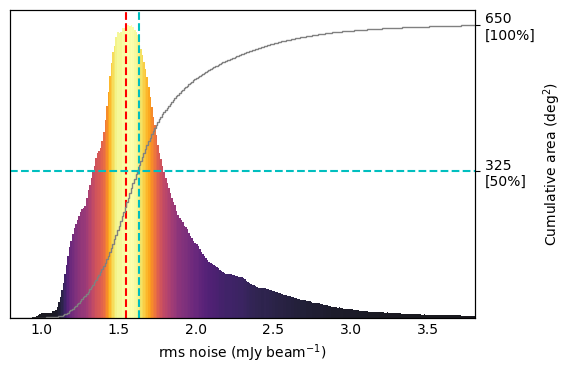

In [4]:
# plot rms
fig = plt.figure(figsize=(6, 4))
fig.subplots_adjust(wspace=0)
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.tick_params(direction='in', top=True, right=True)
fig.subplots_adjust(hspace=0)

ax.set_xlabel(r'rms noise (mJy beam$^{-1}$)')
ax.set_yticklabels([])

bins = np.arange(0.8, 4, 0.01)
n, bins, patches = ax.hist(data[~np.isnan(data)], bins=bins, orientation='vertical', histtype='bar', alpha=.9)

cm = plt.cm.get_cmap('inferno') 
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm(c))

ax2.hist(data[~np.isnan(data)], bins=bins, density=True, histtype='step', cumulative=True, label='Empirical', color='gray')
ax2.set_ylabel(r'Cumulative area (deg$^2$)')
ax2.set_yticks([0.5,1.0])
ax2.set_yticklabels([str(int(x))+' '+y for x,y in zip(np.array([0.5,1.0])*totarea, ['\n[50%]', '\n[100%]'])])

#ax.set_ylim(ymin=0,ymax=4)
median = np.median(data[~np.isnan(data)])
print('Median rms: %f' % median)
thirty = np.quantile(data[~np.isnan(data)],0.3)
print('30%% quantile: %f' % thirty)

fifty = np.quantile(data[~np.isnan(data)],0.5)
print('30%% quantile: %f' % thirty)
commonrms = bins[np.argmax(n)]
print('Most common value: %f' % commonrms)
ax.set_xlim(xmin=0.8,xmax=3.8)
ax.axvline(commonrms, ls="--", color='r')
ax.axvline(fifty, ls="--", color='c')
ax2.axhline(0.5, ls="--", color='c')

#ax2.yaxis.label.set_color('red')
#ax2.tick_params(axis='y', colors='red')
ax.tick_params(axis=u'both', which=u'both',length=0)

#ax.grid(alpha=.2)

fig.savefig('rmshist.pdf', bbox_inches='tight', facecolor='w')

# RMS MAP

In [ ]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(projection=wcs, slices=('x', 'y'))

# normalizer
int_min, int_max = 1, 4
print ('min:',int_min, ' - max:',int_max)
data[data<int_min] = int_min
norm = ImageNormalize(data, vmin=int_min, vmax=int_max, stretch=SqrtStretch())

# bkgr image
im = ax.imshow(data, origin='lower',  interpolation='nearest', cmap='afmhot_r', norm=norm)

# zoom in in pixel
#center = [200, 55] # deg
#setSize(ax, wcs, center[0], center[1], 60, 20)
ax.set_xlim(300, data.shape[1]-300)
ax.set_ylim(0, data.shape[0]-200)

# grid
ax.coords.grid(color='black', ls='solid', alpha=0.15)

# colorbar
cbaxes = fig.add_axes([0.2, 0.85, 0.62, 0.025])
fig.colorbar(im, cax=cbaxes, label=r'rms noise (mJy beam$^{-1}$)', ticks=[1,1.3,2,3,4], format='$%.1f$', orientation='horizontal')
cbaxes.xaxis.tick_bottom()
cbaxes.xaxis.set_label_position('top')

#regions
regs = pyregion.open(reg_pointings).as_imagecoord(header) #  mask point sources
patch_list, artist_list = regs.get_mpl_patches_texts()
for p in patch_list:
    p.set_linewidth=.5
    ax.add_patch(p)
    
ax.plot(212.835495, 52.202770, 'wx', markersize=10, transform=ax.get_transform('fk5')) # 3c295

# labels
lon = ax.coords['ra']
lat = ax.coords['dec']
lon.set_axislabel('Right Ascension (J2000)')
lat.set_axislabel('Declination (J2000)')
lat.set_ticklabel(rotation=90) # to turn dec vertical
lon.set_major_formatter('hh:mm')
lat.set_major_formatter('dd:mm')

fig.savefig('rmsmap.png', bbox_inches='tight', facecolor='w')